Todo: do a full end to end reconstruction of EIT with Tikhonov regularization and save the image. Then change the noise level

In [1]:
using Ferrite
using ModularEIT
using Images
using IterativeSolvers
using LinearAlgebra
using Plots
using Distributions
using Statistics
using Lux
using JLD2

Import all the plumbing for the reverse SDE:
the function $sde(x,t)$ evaluates the SDE

In [2]:
include("model/sde.jl")
sde(randn(64,64),1)

64×64 Matrix{Float32}:
  0.614137  -1.60926    -1.35954    …   0.831205   -1.23225    -0.346751
 -1.62918   -1.54349    -1.56539        0.280387    0.757702    0.222732
  0.523435  -0.744112   -0.785013      -0.532979   -0.462617   -1.6473
 -2.04133   -0.828673    0.325764       0.0943782  -1.05097     0.489309
  0.379503   2.39069     0.967237      -1.50797    -1.11266    -0.636439
  0.763078   0.214147   -0.832157   …   1.16415     1.35862    -0.272852
  1.97407    0.660999   -0.832663      -1.29943     0.553087   -0.370481
 -1.31737   -1.64011    -2.99999       -0.0121339  -0.395439    0.132023
  0.450166  -2.43894     0.27252       -0.212656   -0.0158499  -0.175178
 -0.52135   -1.13986     0.0468923      1.49       -1.25883    -0.75287
  ⋮                                 ⋱                          
 -0.35676    1.64354    -0.66214    …   0.418885   -2.65071    -0.523392
  1.90303    0.26317     1.06782       -0.642002    0.0317483  -0.742864
 -0.696478   0.271843    0.572831      -

Just choose the parameters here: 
The current problem is the scale might vary widely based on the chosen grid. Don't know yet how to normalize it.

In [14]:
σf = 0.0e-2 # how much noise is added to f
σg = 0.0e-2 # How much noise is added to g

ρ_obj = 0.0

0.0

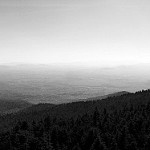

In [4]:
img = load("1096.jpg")

In [5]:
itp = interpolate_array_2D(Float64.(img))

#interpolate_array_2D##0 (generic function with 1 method)

In [6]:
n = 63 
grid = generate_grid(Quadrilateral, (n, n));
∂Ω = union(getfacetset.((grid,), ["left", "top", "right", "bottom"])...)
fe  = FerriteFESpace{RefQuadrilateral}(grid,2,3,∂Ω)
cond_vec = project_function_to_fem(fe, itp)
cond_vec .= min.(max.(cond_vec,1e-6),1.0)

16129-element Vector{Float64}:
 0.662071948030728
 0.6844350473112837
 0.6927977157805238
 0.6702852217531009
 0.6757136120745573
 0.6894434399964395
 0.68419175360409
 0.6672001101490135
 0.6806489158672026
 0.6971524452344504
 ⋮
 0.031167250350174577
 0.015510000235997853
 0.014520427059962128
 0.007829287198868289
 0.00883805925916716
 0.008600073232173745
 0.014341377282337255
 0.012685658965159618
 0.019464199801231867

In [7]:
minimum(cond_vec)

1.0e-6

In [8]:
G_full = real_fourier_basis(8)
rhs_dict = Dict()
Threads.@threads for i in 2:256
    M = make_boundary(G_full[:, i],64)
    itp = interpolate_array_2D(M)
    rhs_dict[i] = assemble_rhs_func(fe, itp)
end

In [9]:
K = assemble_L(fe, cond_vec)
K_fac = cholesky(K)
mode_dict = Dict{Int64,FerriteEITMode}()
mode_dict_no_noise = Dict{Int64,FerriteEITMode}()
@time begin
    Threads.@threads for i in 2:256
        mode_dict[i-1] = create_mode_from_g(fe, rhs_dict[i], K_fac, normalize =  true, σ_f = σf, σ_g= σg)
        mode_dict_no_noise[i-1] = create_mode_from_g(fe, rhs_dict[i], K_fac, normalize =  true)
    end
end

  1.090609 seconds (671.52 k allocations: 853.556 MiB, 33.46% gc time, 19.90% compilation time)


In [10]:
Statistics.std(mode_dict[1].g)

1.899358848972228

In [11]:
#σ_vec = randn(fe.n) #initialize problem with random vector
#@. σ_vec = min(max(σ_vec*0.5 +0.5, 1e-6),1.0)
using Distributions
σ_vec = rand(Uniform(1e-6, 1.0), fe.n)
sol = FerriteSolverState(fe, σ_vec)
prblm = FerriteProblem(fe, mode_dict, sol)

FerriteProblem(FerriteFESpace{RefQuadrilateral}(CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}(Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}(Lagrange{RefQuadrilateral, 2}(), [0.47237900077244527 -1.4605338811812958e-17 … 1.8551212633834227e-18 0.007620999227554982; -0.05999999999999999 1.4605338811812958e-17 … -1.8551212633834227e-18 -0.059999999999999984; … ; 0.2749193338482966 -8.50014503228635e-18 … -8.500145032286352e-18 -0.03491933384829665; 0.15999999999999984 0.3999999999999998 … 0.3999999999999999 0.15999999999999992], [0.47237900077244527 -1.4605338811812958e-17 … 1.855121263383

In [12]:
eval_points = reshape(equidistant_grid(64), :)
ph = PointEvalHandler(grid, eval_points)

PointEvalHandler{Grid{2, Quadrilateral, Float64}, Float64}
  number of points: 4096
  Found corresponding cell for all points.

In [15]:
f,∂f = create_f∂f(prblm, 255; gn=true)
prox_obj = create_prox_linesearch(f, ∂f, ρ_obj)

#create_prox_linesearch##0 (generic function with 1 method)

In [16]:
function grad_A(x)
    # convert to Float 64 and shift:
    xf64 = Float64.(denormalize_image(x))
    itp64 = interpolate_array_2D(xf64)
    σ64 = project_function_to_fem(fe, itp64)
    ∂f(σ64) 
    img64 = reshape(evaluate_at_points(ph, prblm.fe.dh, ∂f(σ64)),(64,64))
    Float32.(normalize_image(img64))
end
function prox_A(x)
    # convert to Float 64 and shift:
    xf64 = Float64.(denormalize_image(x))
    itp64 = interpolate_array_2D(xf64)
    σ64 = project_function_to_fem(fe, itp64)
    prox_A, err, _ = prox_obj(σ64) 
    print("$err ")
    img64 = reshape(evaluate_at_points(ph, prblm.fe.dh, ∂f(σ64)),(64,64))
    Float32.(normalize_image(img64))
end

prox_A (generic function with 1 method)

In [53]:
function reverse_sampler_step!(xt,t, model, Δt, grad_A,ζ)
    β_t = β(t); ᾱ_t = ᾱ(t)    
    ε_pred = model(xt, t)
    x0_hat = (xt .- sqrt(1.0 - ᾱ_t) .* ε_pred) ./ sqrt(ᾱ_t)
    xt_grad = grad_A(x0_hat)
    drift = (0.5 * β_t .* xt) .- ((β_t / sqrt(1.0 - ᾱ_t)) .* ε_pred)
    guidance = ζ(t) * xt_grad
    total_drift = drift .- guidance
    z = randn(size(xt))
    diffusion = sqrt(β_t * Δt) .* z
    xt .+=  (total_drift .* Δt) .+ diffusion
    return xt, t-Δt
end

reverse_sampler_step! (generic function with 1 method)

In [55]:
t = 1
xt = randn(Float32,64,64)
Δt = 0.01
step = 1
while t>0 && step < 110
    step +=1
    xt,t = reverse_sampler_step!(xt,t,sde,Δt,grad_A,ζ)
    print("$step  $t ")
    if mod(step,10) == 0
        println("")
    end
end

2  0.99 3  0.98 4  0.97 5  0.96 6  0.95 7  0.94 8  0.9299999999999999 9  0.9199999999999999 10  0.9099999999999999 
11  0.8999999999999999 12  0.8899999999999999 13  0.8799999999999999 14  0.8699999999999999 15  0.8599999999999999 16  0.8499999999999999 17  0.8399999999999999 18  0.8299999999999998 19  0.8199999999999998 20  0.8099999999999998 
21  0.7999999999999998 22  0.7899999999999998 23  0.7799999999999998 24  0.7699999999999998 25  0.7599999999999998 26  0.7499999999999998 27  0.7399999999999998 28  0.7299999999999998 29  0.7199999999999998 30  0.7099999999999997 
31  0.6999999999999997 32  0.6899999999999997 33  0.6799999999999997 34  0.6699999999999997 35  0.6599999999999997 36  0.6499999999999997 37  0.6399999999999997 38  0.6299999999999997 39  0.6199999999999997 40  0.6099999999999997 
41  0.5999999999999996 42  0.5899999999999996 43  0.5799999999999996 44  0.5699999999999996 45  0.5599999999999996 46  0.5499999999999996 47  0.5399999999999996 48  0.5299999999999996 49  0.5

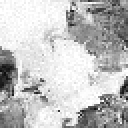

In [56]:
solution = Gray.(clamp.(denormalize_image(xt),0.0,1.0))

In [57]:
using Printf
fmt(x) = @sprintf("%.3e", x) 
fname = "DPS/$(fmt(σf))_$(fmt(σg))_$(fmt(η)).png"
save(fname, solution)